## 인공 신경망(Artificial Neural Network)
![Neuron](img/Neuron.png)

> 인공 신경망은 생물학적 신경망에서 영감을 얻어 만들어졌다. </br>
> - 생물학적 신경망 : 여러 자극이 '가지돌기'들을 통해 신경세포로 들어오고 어느 정도 이상의 자극이 들어오면 축삭을 통해 다른 세포로 전달하는 구조.</br></br>
> - 인공 신경망 : 여러 자극 혹은 입력이 들어오면 각각 가중치를 곱해 더해주고 추가적으로 편차도 더해준다. 이렇게 다 더한 값을 활성 함수를 통해 변형하여 전달하는 단위.

***
***인공 신경망의 요소**  
- 인공 신경망은 아래 그림처럼 여러 개의 입력값과 출력값을 가질 수 있으며, 입력 단과 출력 단 사이의 은닉층(hidden layer)의 수에 따라 신경망과 심층 신경망으로 나뉜다.

![NN](img/ShallowNN.png)

- 심층 신경망은 2개 이상의 은닉층을 가진 인공 신경망을 의미한다. 하나의 셀(뉴런)에서와 마찬가지로 입력값들의 가중치 합을 활성 함수에 통과시켜 변형시키고, 이 과정을 반복적으로 진행하여 최종 결과값을 도출한다.
- 이를 수식으로 표현해본다면 아래와 같다.

![NN2](img/NN2.png)

- 수식을 살펴보면 'y = w * x + b'의 형태가 계속 반복되는데 이를 행렬연산으로 표현해보자.
- 각 행렬의 <shape : x (m x n), wT (n x l), b (m x l)>
- x와 w의 위치가 바뀐 것은 입력값인 x에서 열 단위로 데이터가 구분되기 때문이다 -> 첫 행이 첫 번째 데이터의 입력값에 해당하고 각 입력값에 비중을 곱하고 최종적으로 편차를 더하기 때문에 순서가 바뀐 것이다.


***
***활성 함수(activation function)**
- 위에서 계산된 값들은 활성 함수를 거쳐 '비선형성(nonlinearity)'을 띠게 된다. 이러한 활성 함수가 없다면 은닉층이 몇 개더라도 결국 선형 변환이기 때문에 깊은 모델을 만든 의미가 사라진다.

![activate](img/activate.png)

- 활성 함수 중 인공 신경망에서 많이 사용되는 함수로는 '시그모이드(sigmoid)'와 '하이퍼볼릭 탄젠트(tanh)'가 있다.
- 시그모이드 함수는 결과값이 0에서 1인 완만한 곡선 형태이며, 하이퍼볼릭 탄젠트 함수는 -1에서 1의 값을 갖는다.
- 두 함수는 모든 구간에서 미분이 가능하기 때문에 역전파를 하기에 유용하다.
- 최근에는 '렐루(ReLU)'함수가 많이 사용된다.
***

***전파와 역전파**
> 인공 신경망은 입력값이 들어오면 여러 개의 은닉층을 순서대로 거쳐 결과값을 내는데 이 과정을 '전파(forward propagation)'이라고 한다.

![NN3](img/NN3.png)

![NN4](img/weight.png)

- 2개의 은닉층을 갖는 인공 신경망과 이 신경망에서 연산에 사용되는 가중치들을 행렬로 표현한 그림이다.
- 이제부터 '전파'과정을 살펴보자.

***
> 전파의 과정은 1.텐서 간의 곱 2. 편차의 덧셈 3. 활성 함수의 적용, 이렇게 3가지로 구성된다.</br>

- (5x3)의 shape를 갖는 입력을 가정하자.
- 5는 데이터의 개수, 3은 각 데이터의 특성의 개수를 의미한다.

![weight2](img/weight2.png)

- 위의 그림처럼 (5x3)형태의 입력과 (3x4)형태의 가중치가 곱해져 (5x4)형태의 결과가 나온다.
- 여기에 다시 (4x4)형태의 가중치가 곱해져 (5x4)형태의 결과가 나오고, 마지막으로 (4x2)형태의 가중치가 곱해져 최종결과는 (5x2)가 됨을 알 수 있다! 
- 가중치 : w, 편차 : b, 활성화 함수 : σ로 놓고 전파의 과정을 수식으로 표현하면 다음과 같다.

![전파](img/propagation.png)
- 이렇게 예측값이 y'을 구하는 과정이 바로 '전파'이다.
***

***손실 계산**
> 이제는 손실을 계산할 차례다. 정답을 y라고 했을 때 손실을 계산하고, 경사하강법을 쓰기 위해 변수인 가중치와 편차에 대해 손실을 미분해보면 아래와 같이 전개된다.

![loss](img/loss%EA%B3%84%EC%82%B0.png)
- 가중치3과 편차3은 바로 미분이 가능하다. 하지만, 가중치2 같은 경우에는 바로 미분할 수 없다.
- 이는 '연쇄법칙(chain rule)'을 통해 해결할 수 있다.

![weight3](img/weight3.png)

- 전파와 역전파의 구체적인 계산 예시
https://wikidocs.net/37406

***
## Pytorch에서 모델 구현하기
> 선형회귀에서는 선형 데이터를 다뤘지만 이번에는 선형으로 표현할 수 없는 2차 함수의 형태를 가지는 데이터를 이용하겠다. </br>

- 들어오는 입력 특성은 이전과 같이 하나의 x값이 들어오고 최종적으로 하나의 결과값인 y'이 나오지만 중간에 몇 개의 은닉층이 존재한다.
- 입력값 x가 들어오면 'w * x + b'연산이 이루어지고 이후 활성 함수를 통과함으로써 비선형성을 얻는다.
- 연산의 결과는 또 다른 은닉층을 통과하고 최종적으로 1개의 결과값이 나올 때까지 진행된다.
- 이렇게 나온 값 y'은 정답 값이 y와 손실 함수에 따라 차이가 계산된다.
- 그러면 손실을 각 변수들로 미분하여 기울기를 구한다.
- 전파와 역전파 과정을 말로 설명하면 이렇게 길지만, 파이토치는 이 과정을 함수 하나만 호출하면 알아서 처리해준다!!

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.init as init
import matplotlib.pyplot as plt

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(DEVICE)

cuda


In [3]:
num_data = 1000
num_epoch = 10000

noise = init.normal(torch.FloatTensor(num_data, 1), std=1).to(DEVICE)
x = init.uniform_(torch.Tensor(num_data, 1), -15, 15).to(DEVICE)
y = (x**2) + 3
y_noise = y + noise
y_noise = y_noise.to(DEVICE)

model = nn.Sequential(
    nn.Linear(1,6),
    nn.ReLU(),
    nn.Linear(6, 10),
    nn.ReLU(),
    nn.Linear(10,6),
    nn.ReLU(),
    nn.Linear(6,1),
)
model = model.to(DEVICE)

loss_func = nn.L1Loss()
optimizer = optim.SGD(model.parameters(),lr=0.002)

loss_array = []
for i in range(num_epoch) :
    optimizer.zero_grad()
    output = model(x)
loss = loss_func(output, y_noise)
loss.backward()
optimizer.step()

loss_array.append(loss.detach().cpu().numpy())


C:\Users\Asus\AppData\Local\Temp\ipykernel_14812\3426615190.py:4: UserWarning: nn.init.normal is now deprecated in favor of nn.init.normal_.
  noise = init.normal(torch.FloatTensor(num_data, 1), std=1).to(DEVICE)


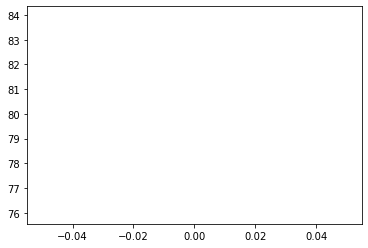

In [4]:
plt.plot(loss_array)
plt.show()

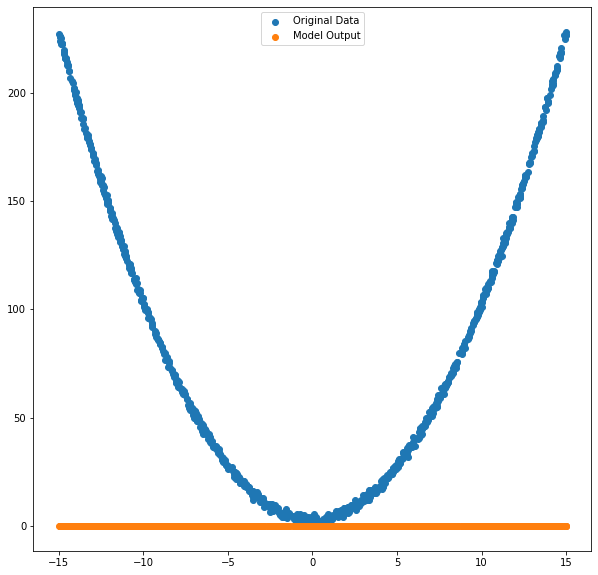

In [6]:
plt.figure(figsize=(10,10))
plt.scatter(x.detach().cpu().numpy(), y_noise.cpu() , label="Original Data")
plt.scatter(x.detach().cpu().numpy(), output.detach().cpu().numpy(), label="Model Output")
plt.legend()
plt.show()

- 인공 신경망으로 y = x^2 + 3을 근사하는 과정의 그림이다.
- 목표로 하는 함수를 검은 점들로 표현하고 여기에 노이즈를 추가한 데이터를 붉은색 계열로 표시한 것이다.
- 중간중간 꺾인 부분은 ReLU함수의 영향이다. ReLU함수 특성상 입력값이 0보다 작은 값들을 모두 0으로 만들기 때문에 여러 은닉층을 통과하면서 여러 지점에서 꺾인 모양이 나타나게 된다.

***참고문헌***
- 파이토치 첫걸음